# GoPay Google Play Review - Exploratory Data Analysis (EDA)

**Author:** Muhammad Razan Parisya Putra  
**Notebook:** `2 - Exploratory Data Analysis`

This notebook continues from the review scraping process covered in [1-Gopay-Review-Scrapping.ipynb](https://colab.research.google.com/drive/10nbC1y77iPDIETCM74LFBPK3i3sylXfh?usp=sharing)

## 1. Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Tugas 1/Dataset/gopay_reviews_raw.csv')
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,888c9e2d-b048-4ff5-9dc2-19582ad89693,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Baru kali ini pakai gopay kek gini, tadi saya ...",1,0,2.3.0,2026-02-28 15:16:28,"Hai Kak Joko, pastikan nomor tujuan sudah bena...",2026-02-28 15:04:54,2.3.0
1,b3a1f5ab-6c0f-489a-9539-79ab670053a8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,busuk,1,0,2.3.0,2026-02-28 15:14:08,NaN,NaN,2.3.0
2,e5045dd9-d082-4158-be52-6d455729cd53,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,selalu dapat bonus,5,0,2.3.0,2026-02-28 15:12:17,NaN,NaN,2.3.0
3,5fa3f408-c649-4c02-b7fc-f644fbb0ec57,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"good, kasih donk promonya",5,0,2.3.0,2026-02-28 15:10:00,NaN,NaN,2.3.0
4,13dafdbe-e031-4a44-ae1f-630fb257a6ec,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,terbaik mendukung bwnget,5,0,2.0.3,2026-02-28 15:08:01,NaN,NaN,2.0.3
...,...,...,...,...,...,...,...,...,...,...,...
367190,5c496d7c-b569-4189-848d-cb7ba43ee5be,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Ribet asw mau buka akun aja susah baru kli ini...,1,3,NaN,2023-04-08 13:27:16,"Hai Irfa, saat ini aplikasi GoPay masih berada...",2023-04-10 04:40:43,NaN
367191,ff92fd6c-c714-44c6-a740-164111046cf5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Kok gk ada ulasan lain?,5,1,NaN,2023-04-08 09:37:00,NaN,NaN,NaN
367192,6d7088a1-feff-4a2f-8b8b-c9e0a6ffe1ff,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Susah masuknya malah anti trus,1,11,1.0.0,2023-04-08 08:41:47,"Hai Erwin, saat ini aplikasi GoPay masih berad...",2023-04-10 04:43:43,1.0.0
367193,82870e75-2a01-4968-a6d7-8ccea03e43d9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Terima kasih,2,4,NaN,2023-04-08 06:23:30,NaN,NaN,NaN


## 2. Data Overview & Quality Check

Before any analysis, we need to understand the basic structure of the dataset, check for data types, missing values, and duplicates.

In [ ]:
# Basic structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367195 entries, 0 to 367194
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              367195 non-null  object
 1   userName              367195 non-null  object
 2   userImage             367195 non-null  object
 3   content               367194 non-null  object
 4   score                 367195 non-null  int64 
 5   thumbsUpCount         367195 non-null  int64 
 6   reviewCreatedVersion  306103 non-null  object
 7   at                    367195 non-null  object
 8   replyContent          61660 non-null   object
 9   repliedAt             61660 non-null   object
 10  appVersion            306103 non-null  object
dtypes: int64(2), object(9)
memory usage: 30.8+ MB


In [ ]:
# First few rows to understand the content
df.head(3)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,888c9e2d-b048-4ff5-9dc2-19582ad89693,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Baru kali ini pakai gopay kek gini, tadi saya ...",1,0,2.3.0,2026-02-28 15:16:28,"Hai Kak Joko, pastikan nomor tujuan sudah bena...",2026-02-28 15:04:54,2.3.0
1,b3a1f5ab-6c0f-489a-9539-79ab670053a8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,busuk,1,0,2.3.0,2026-02-28 15:14:08,NaN,NaN,2.3.0
2,e5045dd9-d082-4158-be52-6d455729cd53,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,selalu dapat bonus,5,0,2.3.0,2026-02-28 15:12:17,NaN,NaN,2.3.0


In [ ]:
# Statistical summary of numeric columns
df.describe()

,score,thumbsUpCount
count,367195.000000,367195.000000
mean,4.198557,0.879132
std,1.469517,40.069413
min,1.000000,0.000000
25%,4.000000,0.000000
50%,5.000000,0.000000
75%,5.000000,0.000000
max,5.000000,18391.000000


In [ ]:
# Missing values analysis
missing = df.isnull().sum()
missing

,0
reviewId,0
userName,0
userImage,0
content,1
score,0
thumbsUpCount,0
reviewCreatedVersion,61092
at,0
replyContent,305535
repliedAt,305535


In [ ]:
# Duplicate reviews check
dup_reviewid = df['reviewId'].duplicated().sum()
dup_content = df['content'].duplicated().sum()

print(f'Duplicate reviewIds   : {dup_reviewid:,}')
print(f'Duplicate content text: {dup_content:,}')

# Show examples of duplicated content (if any)
if dup_content > 0:
    print(f'\nTop 5 most repeated review texts:')
    print(df['content'].value_counts().head())

Duplicate reviewIds   : 0
Duplicate content text: 148,550

Top 5 most repeated review texts:
content
mantap    11119
bagus      9709
Mantap     7745
ok         5645
Bagus      5505
Name: count, dtype: int64


In [ ]:
# Identify empty or whitespace-only reviews
empty_mask = df['content'].isna() | (df['content'].str.strip() == '')
print(f'Empty/whitespace-only reviews: {empty_mask.sum():,} ({empty_mask.mean()*100:.2f}%)')

Empty/whitespace-only reviews: 1 (0.00%)


## 3. Score Distribution Analysis

In [ ]:
count = df['score'].value_counts().sort_index()
df_count = pd.DataFrame(count).reset_index()
df_count.columns = ['score', 'count']
df_count = df_count[['score', 'count']]
df_count

,score,count
0,1,54526
1,2,9161
2,3,12619
3,4,23461
4,5,267428


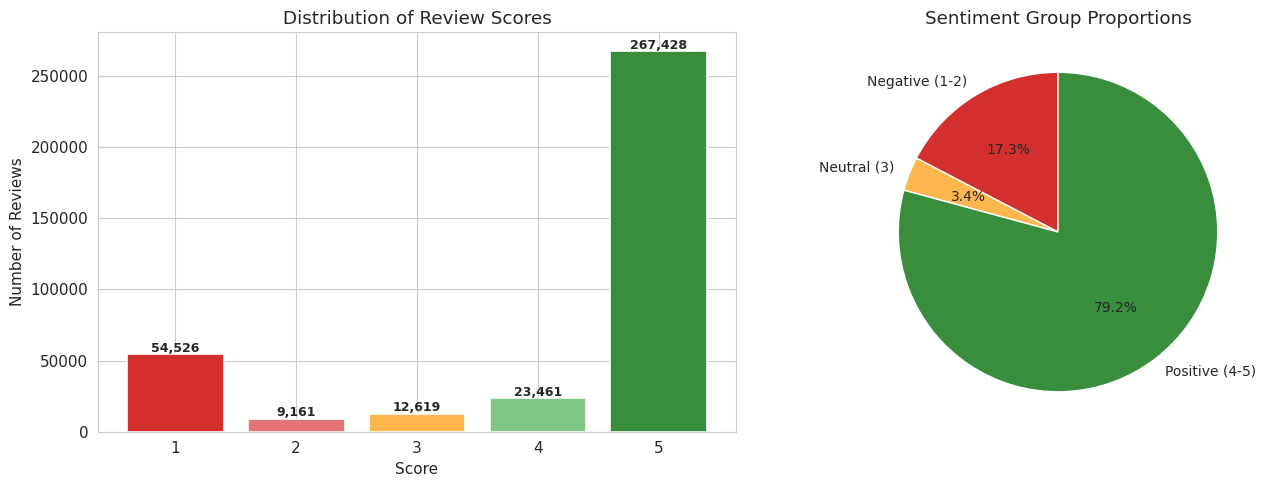


Sentiment grouping: Negative = 63,687  Neutral = 12,619  Positive = 290,889


In [ ]:
# Score distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#d32f2f', '#e57373', '#ffb74d', '#81c784', '#388e3c']
axes[0].bar(df_count['score'], df_count['count'], color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_title('Distribution of Review Scores')
axes[0].set_xticks(range(1, 6))
for _, row in df_count.iterrows():
    axes[0].text(row['score'], row['count'] + len(df) * 0.005, f"{row['count']:,}",
                 ha='center', fontsize=9, fontweight='bold')

# Pie chart — grouped into Negative (1-2), Neutral (3), Positive (4-5)
negative = df_count[df_count['score'].isin([1, 2])]['count'].sum()
neutral  = df_count[df_count['score'] == 3]['count'].sum()
positive = df_count[df_count['score'].isin([4, 5])]['count'].sum()

labels = ['Negative (1-2)', 'Neutral (3)', 'Positive (4-5)']
sizes = [negative, neutral, positive]
pie_colors = ['#d32f2f', '#ffb74d', '#388e3c']
axes[1].pie(sizes, labels=labels, colors=pie_colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Sentiment Group Proportions')

plt.tight_layout()
plt.show()

print(f'\nSentiment grouping: Negative = {negative:,}  Neutral = {neutral:,}  Positive = {positive:,}')

## 4. Temporal Analysis

Understanding when reviews were posted helps identify trends, spikes (e.g., after a major update or incident), and the overall growth of user engagement.

In [ ]:
# 4.1 — Parse dates
df['at'] = pd.to_datetime(df['at'])
df['year'] = df['at'].dt.year
df['month'] = df['at'].dt.to_period('M')

print(f'Review date range: {df["at"].min().date()} to {df["at"].max().date()}')
print(f'Total span: {(df["at"].max() - df["at"].min()).days:,} days')

Review date range: 2023-04-07 to 2026-02-28
Total span: 1,057 days


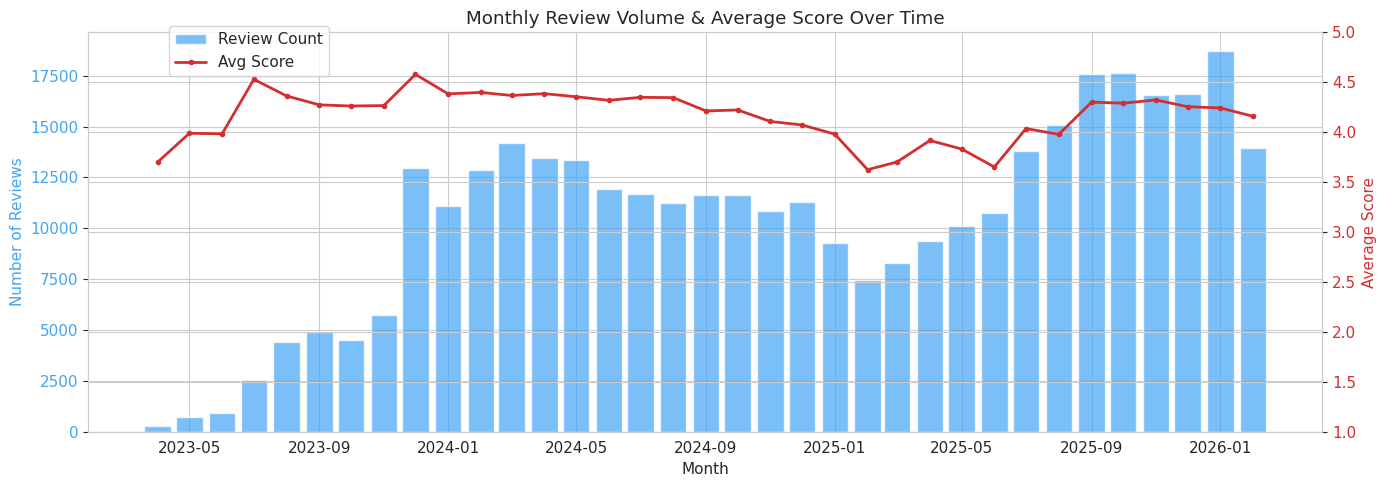

In [ ]:
# 4.2 — Monthly review volume
monthly = df.groupby('month').agg(
    review_count=('content', 'count'),
    avg_score=('score', 'mean')
).reset_index()
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 5))

# Review count (bars)
ax1.bar(monthly['month_dt'], monthly['review_count'], width=25,
        color='#42a5f5', alpha=0.7, label='Review Count')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Reviews', color='#42a5f5')
ax1.tick_params(axis='y', labelcolor='#42a5f5')

# Average score (line overlay)
ax2 = ax1.twinx()
ax2.plot(monthly['month_dt'], monthly['avg_score'], color='#d32f2f',
         linewidth=2, marker='o', markersize=3, label='Avg Score')
ax2.set_ylabel('Average Score', color='#d32f2f')
ax2.set_ylim(1, 5)
ax2.tick_params(axis='y', labelcolor='#d32f2f')

plt.title('Monthly Review Volume & Average Score Over Time')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.95))
plt.tight_layout()
plt.show()

In [ ]:
# 4.3 — Yearly breakdown
yearly = df.groupby('year').agg(
    review_count=('content', 'count'),
    avg_score=('score', 'mean')
).round(2)

print('Yearly Summary:')
yearly

Yearly Summary:


,review_count,avg_score
year,,
2023,36922,4.39
2024,145129,4.30
2025,152496,4.06
2026,32647,4.21


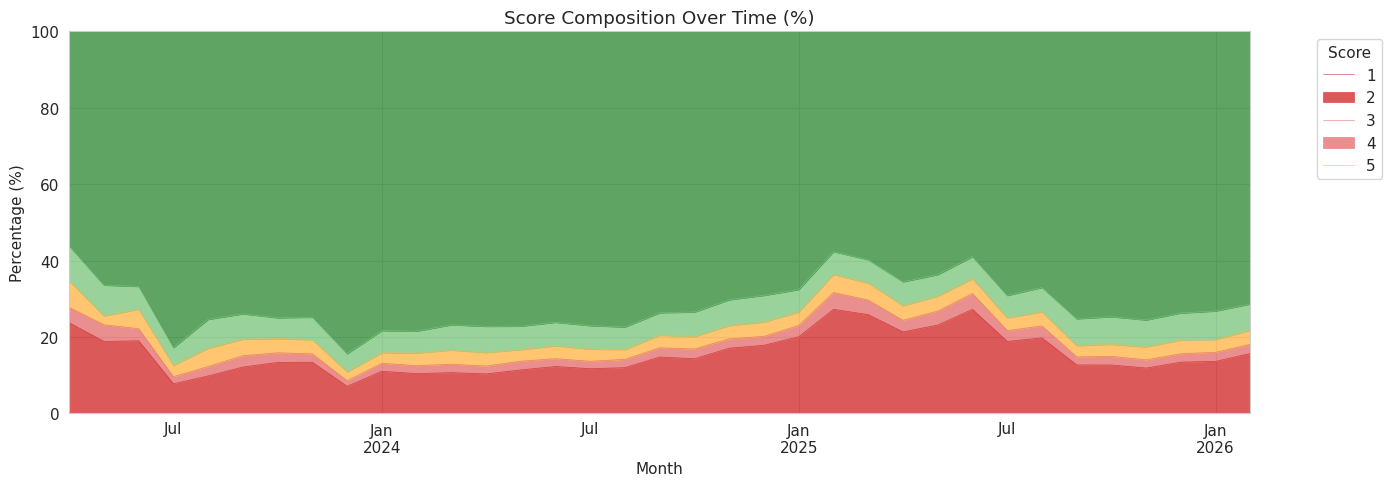

In [ ]:
# 4.4 — Score composition over time (stacked area)
monthly_scores = df.groupby(['month', 'score']).size().unstack(fill_value=0)
monthly_scores.index = monthly_scores.index.to_timestamp()
monthly_pct = monthly_scores.div(monthly_scores.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 5))
monthly_pct.plot.area(ax=ax, color=colors, alpha=0.8, linewidth=0.5)
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Month')
ax.set_title('Score Composition Over Time (%)')
ax.legend(title='Score', labels=['1','2','3','4','5'], bbox_to_anchor=(1.05, 1))
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

In [ ]:
# 5.1 — Review length analysis
df['review_length'] = df['content'].astype(str).str.len()
df['word_count'] = df['content'].astype(str).str.split().str.len()

print('Review Length (characters):')
print(df['review_length'].describe().round(1))
print(f'\nReview Word Count:')
print(df['word_count'].describe().round(1))

Review Length (characters):
count    367195.0
mean         43.4
std          63.6
min           1.0
25%           7.0
50%          19.0
75%          51.0
max         500.0
Name: review_length, dtype: float64

Review Word Count:
count    367195.0
mean          7.1
std          10.3
min           1.0
25%           1.0
50%           3.0
75%           8.0
max         107.0
Name: word_count, dtype: float64


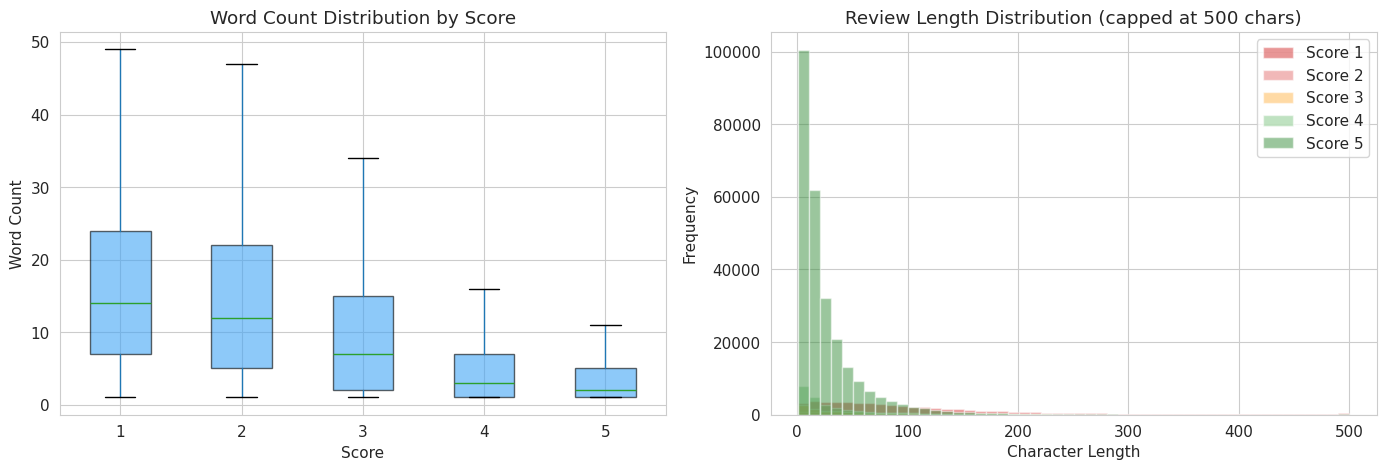


Average word count by score:
score
1    18.2
2    16.1
3    11.1
4     6.1
5     4.4
Name: word_count, dtype: float64


In [ ]:
# 5.2 — Review length distribution by score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of word count per score
df.boxplot(column='word_count', by='score', ax=axes[0],
           showfliers=False, patch_artist=True,
           boxprops=dict(facecolor='#42a5f5', alpha=0.6))
axes[0].set_title('Word Count Distribution by Score')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Word Count')
axes[0].get_figure().suptitle('')  # remove auto title

# Histogram of review lengths (capped at 500 chars for readability)
for s in range(1, 6):
    subset = df[df['score'] == s]['review_length']
    axes[1].hist(subset.clip(upper=500), bins=50, alpha=0.5, label=f'Score {s}', color=colors[s-1])
axes[1].set_title('Review Length Distribution (capped at 500 chars)')
axes[1].set_xlabel('Character Length')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nAverage word count by score:')
print(df.groupby('score')['word_count'].mean().round(1))

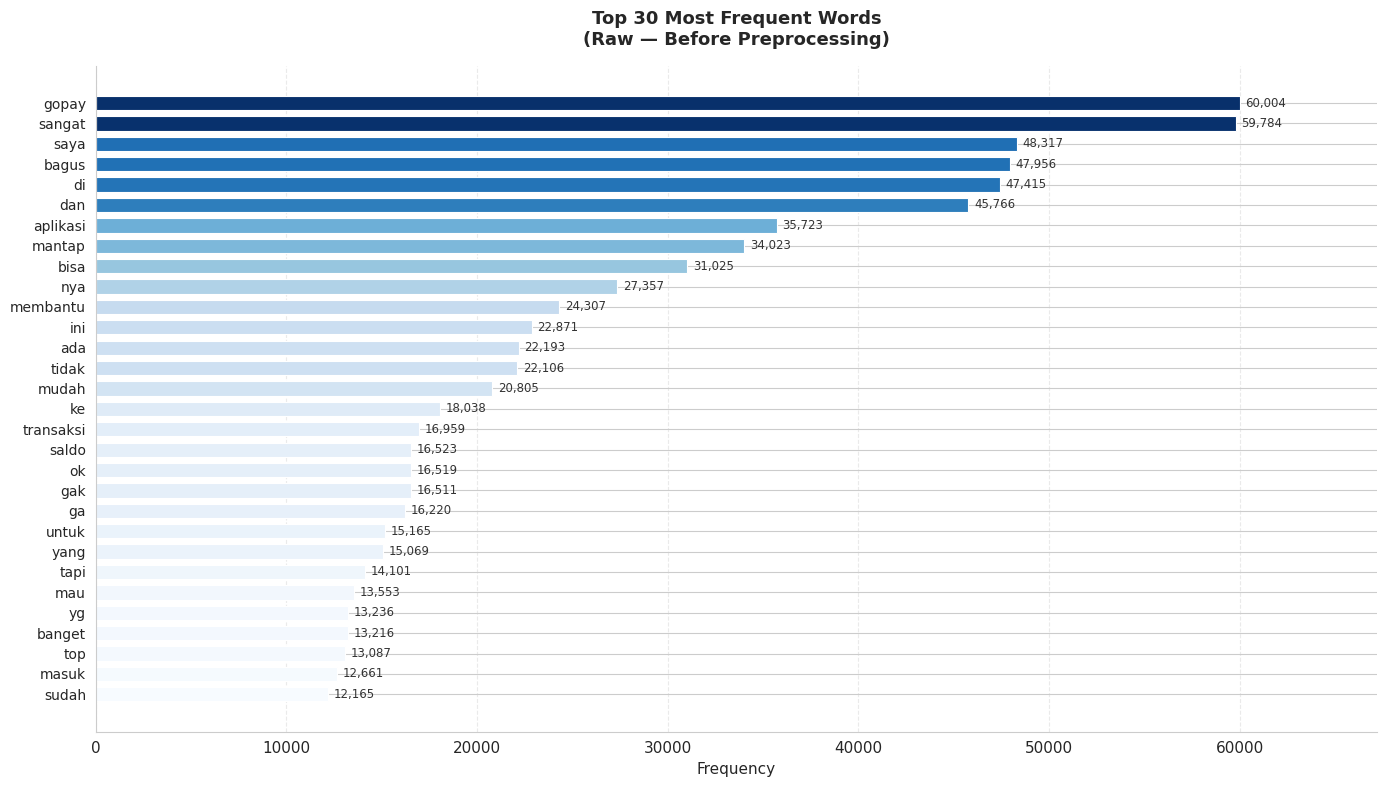

In [ ]:
# 5.3 — Most common words (raw, before preprocessing)
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

all_words = ' '.join(df['content'].astype(str).str.lower()).split()
word_freq = Counter(all_words)

top_30 = word_freq.most_common(30)
words, counts = zip(*top_30)

# Gradient color based on frequency
norm = plt.Normalize(min(counts), max(counts))
colors = cm.Blues(norm(counts))

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(words)), counts, color=colors, edgecolor='white', linewidth=0.8, height=0.7)

# Add count labels at the end of each bar
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(bar.get_width() + max(counts) * 0.005, i, f'{count:,}',
            va='center', fontsize=8.5, color='#333333')

ax.set_yticks(range(len(words)))
ax.set_yticklabels(words, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Frequency', fontsize=11)
ax.set_title('Top 30 Most Frequent Words\n(Raw — Before Preprocessing)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, max(counts) * 1.12)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

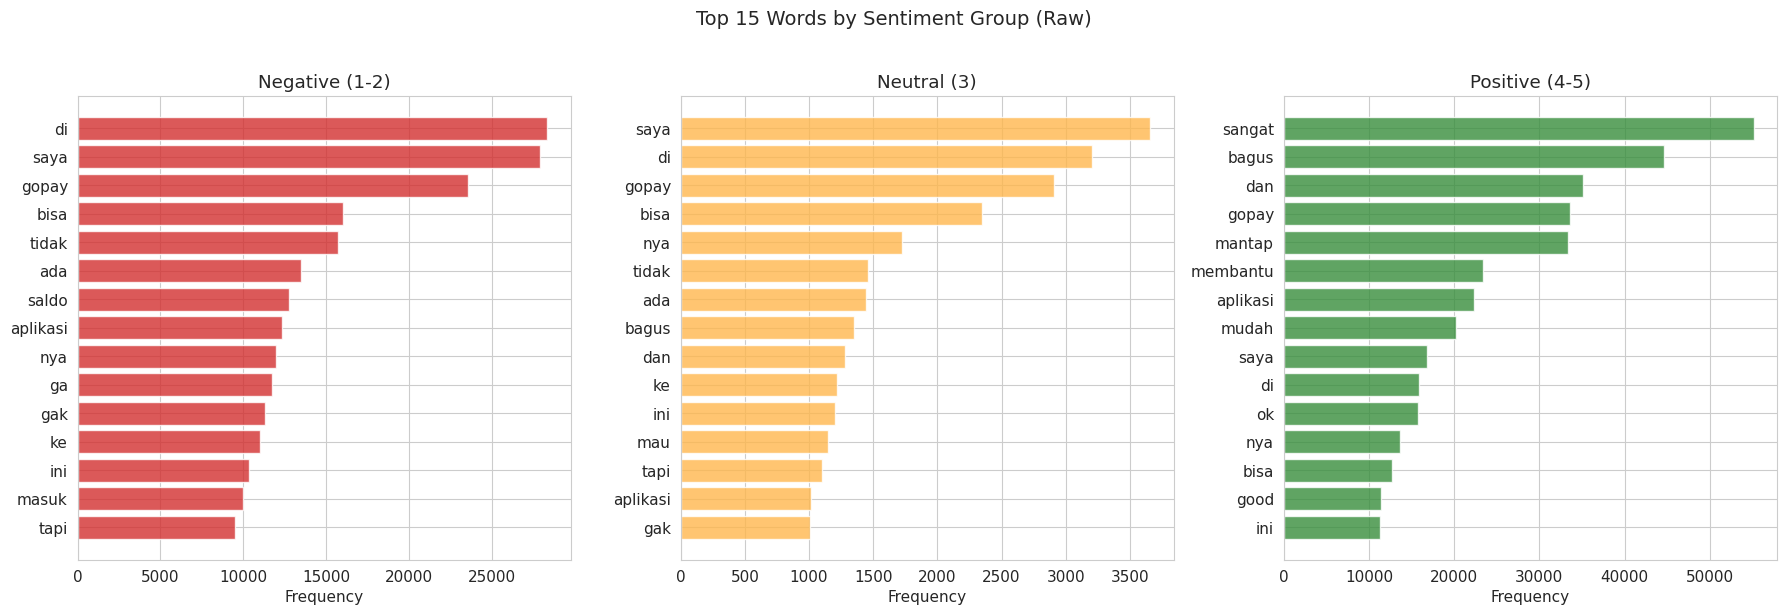

In [ ]:
# 5.4 — Most common words split by sentiment group
def get_top_words(subset_df, n=15):
    text = ' '.join(subset_df['content'].astype(str).str.lower())
    return Counter(text.split()).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
groups = {
    'Negative (1-2)': df[df['score'].isin([1, 2])],
    'Neutral (3)': df[df['score'] == 3],
    'Positive (4-5)': df[df['score'].isin([4, 5])]
}
group_colors = ['#d32f2f', '#ffb74d', '#388e3c']

for ax, (label, group_df), color in zip(axes, groups.items(), group_colors):
    top_w = get_top_words(group_df)
    w, c = zip(*top_w)
    ax.barh(range(len(w)), c, color=color, alpha=0.8)
    ax.set_yticks(range(len(w)))
    ax.set_yticklabels(w)
    ax.invert_yaxis()
    ax.set_title(label)
    ax.set_xlabel('Frequency')

plt.suptitle('Top 15 Words by Sentiment Group (Raw)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# 5.5 — Examples of very short and very long reviews
print('=== SHORTEST REVIEWS (1-2 words) ===')
short = df[df['word_count'] <= 2][['content', 'score']].sample(min(10, len(df[df['word_count'] <= 2])), random_state=42)
for _, row in short.iterrows():
    print(f'  [{row["score"]}] {row["content"]}')

print(f'\n=== LONGEST REVIEWS (top 5 by word count) ===')
long = df.nlargest(5, 'word_count')[['content', 'score', 'word_count']]
for _, row in long.iterrows():
    print(f'  [{row["score"]}] ({row["word_count"]} words) {row["content"][:150]}...')

=== SHORTEST REVIEWS (1-2 words) ===
  [5] Mudah, cepat
  [5] Mantap
  [5] bagus👍
  [5] 👍
  [5] banyak promonya
  [5] mantap
  [4] oke mantap
  [5] Sangat membantu
  [5] Top
  [3] bagus

=== LONGEST REVIEWS (top 5 by word count) ===
  [5] (107 words) Sy bingung dgn Gopaylater , tolong dilht sy byr tepat waktu trs loh !!! tgl 1 lunas tiap bln nya selalu , tp admin ga mau nge check sama skl !!!sy jan...
  [2] (105 words) Stock Cheek Pad Dll Eps Sid Bluetooth: 1000 Eps Sid Bluetooth Besar: 0 Eps Chin TTC: 900 Eps Chin Enduro: 0 Eps Chin Striker: 0 Cheek Pad RC 10: 0 Che...
  [1] (102 words) tgl 4/11/2025 saya top up dr brimo sampai skrng msoh d proses. d gopay blng 48 KLO g masuk d balikin k brimo sampai skrg saya d tagih ". Krn uang blm ...
  [4] (102 words) Gopay sejauh ini bgs, bs d blng luar biasa , cuma sayang ny satu Krn telat byr sbntr lngsng tdk bs pinjam, limit terkunci, jatuh tempo tgl 18 Juni, sy...
  [5] (100 words) Mantappppp Mah mau tau apa arti dari kata anarkis tapi kok ma

Total unique app versions: 94
Reviews with missing version: 61,092


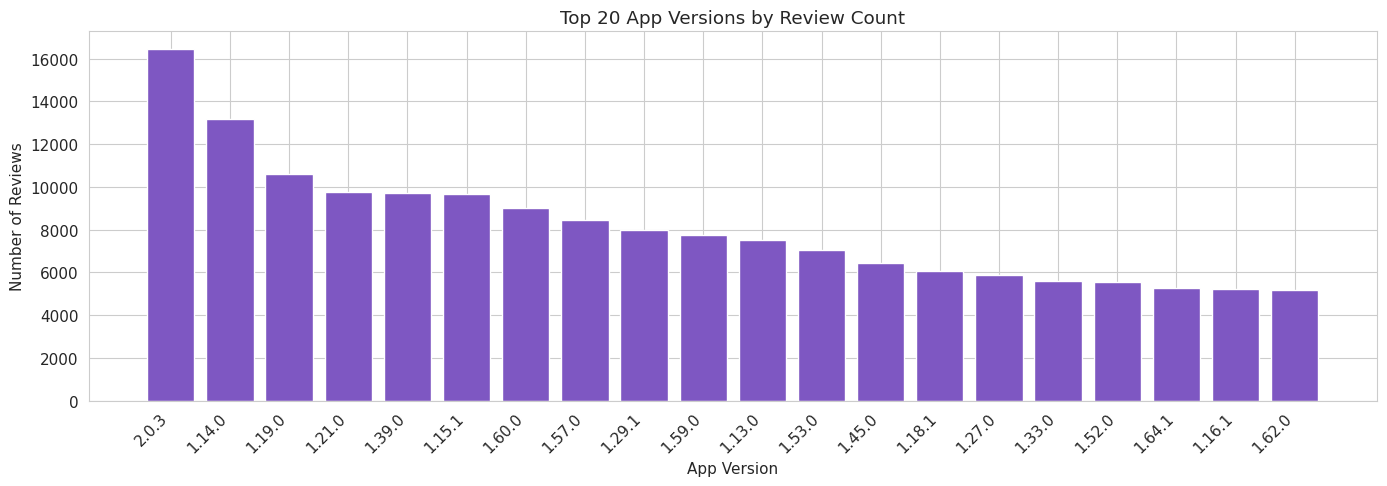

In [ ]:
# 6.1 — Reviews per app version (top 20)
version_counts = df['reviewCreatedVersion'].value_counts()
print(f'Total unique app versions: {version_counts.shape[0]}')
print(f'Reviews with missing version: {df["reviewCreatedVersion"].isna().sum():,}')

top_versions = version_counts.head(20)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(top_versions)), top_versions.values, color='#7e57c2')
ax.set_xticks(range(len(top_versions)))
ax.set_xticklabels(top_versions.index, rotation=45, ha='right')
ax.set_xlabel('App Version')
ax.set_ylabel('Number of Reviews')
ax.set_title('Top 20 App Versions by Review Count')
plt.tight_layout()
plt.show()

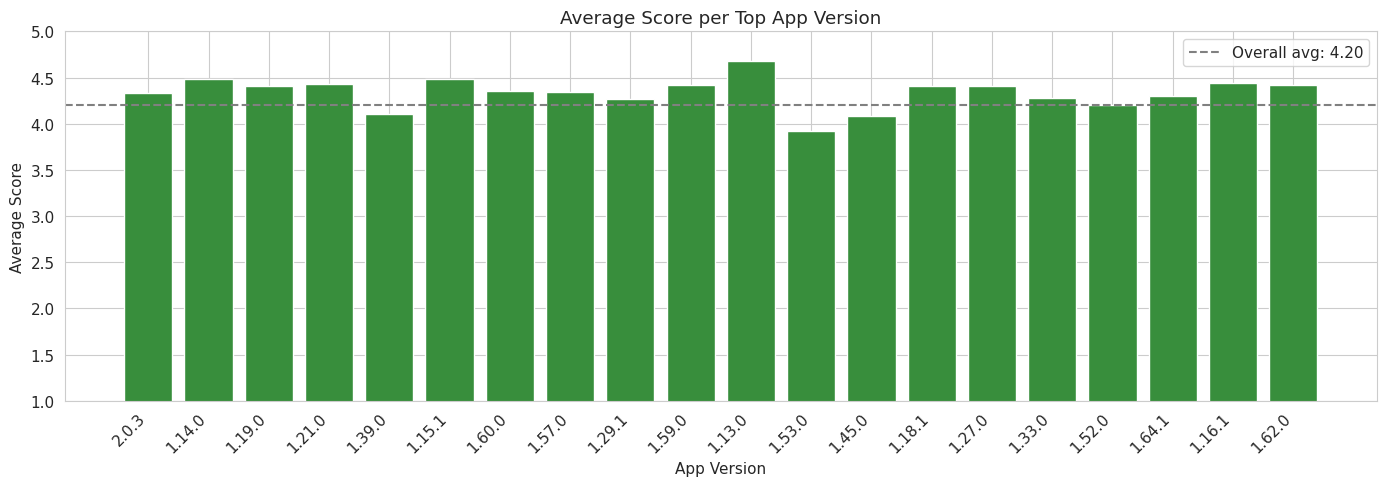

In [ ]:
# 6.2 — Average score per top app version
top_ver_list = top_versions.index.tolist()
ver_scores = df[df['reviewCreatedVersion'].isin(top_ver_list)].groupby('reviewCreatedVersion')['score'].agg(['mean', 'count'])
ver_scores = ver_scores.loc[top_ver_list]  # keep original order

fig, ax = plt.subplots(figsize=(14, 5))
bar_colors = ['#388e3c' if s >= 3.5 else '#ffb74d' if s >= 2.5 else '#d32f2f' for s in ver_scores['mean']]
ax.bar(range(len(ver_scores)), ver_scores['mean'], color=bar_colors)
ax.axhline(y=df['score'].mean(), color='gray', linestyle='--', label=f'Overall avg: {df["score"].mean():.2f}')
ax.set_xticks(range(len(ver_scores)))
ax.set_xticklabels(ver_scores.index, rotation=45, ha='right')
ax.set_xlabel('App Version')
ax.set_ylabel('Average Score')
ax.set_ylim(1, 5)
ax.set_title('Average Score per Top App Version')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Referensi

Analisis EDA di notebook ini mengadaptasi teknik dan pendekatan dari beberapa sumber:

- **Google App Store EDA** (Gaurob Saha) -- analisis distribusi rating, review count, dan text analysis pada app store reviews.  
  [kaggle.com/code/gaurobsaha/google-app-store-eda](https://www.kaggle.com/code/gaurobsaha/google-app-store-eda)

- **Data Analysis on Indonesia Startup Apps Reviews** (Rezky Yayang) -- analisis review per tahun (N=reviews per Year), temporal patterns, dan distribusi sentimen untuk aplikasi startup Indonesia.  
  [kaggle.com/code/rezkyyayang/data-analysis-on-indonesia-startup-apps-reviews](https://www.kaggle.com/code/rezkyyayang/data-analysis-on-indonesia-startup-apps-reviews)

- **EDA IH** -- contoh colab EDA dari mata kuliah.  
  [colab.research.google.com/drive/1pzSiJTwgSVqiWXnuZ8jPqc_yfMcYcX24](https://colab.research.google.com/drive/1pzSiJTwgSVqiWXnuZ8jPqc_yfMcYcX24)

Teknik yang diadaptasi meliputi: visualisasi distribusi rating, analisis temporal (review volume per bulan/tahun),
analisis panjang review per skor, dan identifikasi kata paling sering muncul berdasarkan kelompok sentimen.